In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import root_mean_squared_error, mean_squared_error, r2_score

import joblib

df = pd.read_csv('./datasets/housing.csv')
print(f"Shape: {df.shape}")
print("\nNull Values:")
print(df.isnull().sum())

Shape: (20640, 10)

Null Values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


# 1. Exploratory Data Analysis (EDA)
### 1.1 Creating new features

In [2]:
df['rooms_per_household'] = df['total_rooms']/df['households'] # avg number of rooms per household
df['population_per_household'] = df['population']/df['households'] # avg number of people living per household
df['bedroom_per_room'] = df['total_bedrooms']/df['total_rooms']

### 1.2 Visualization

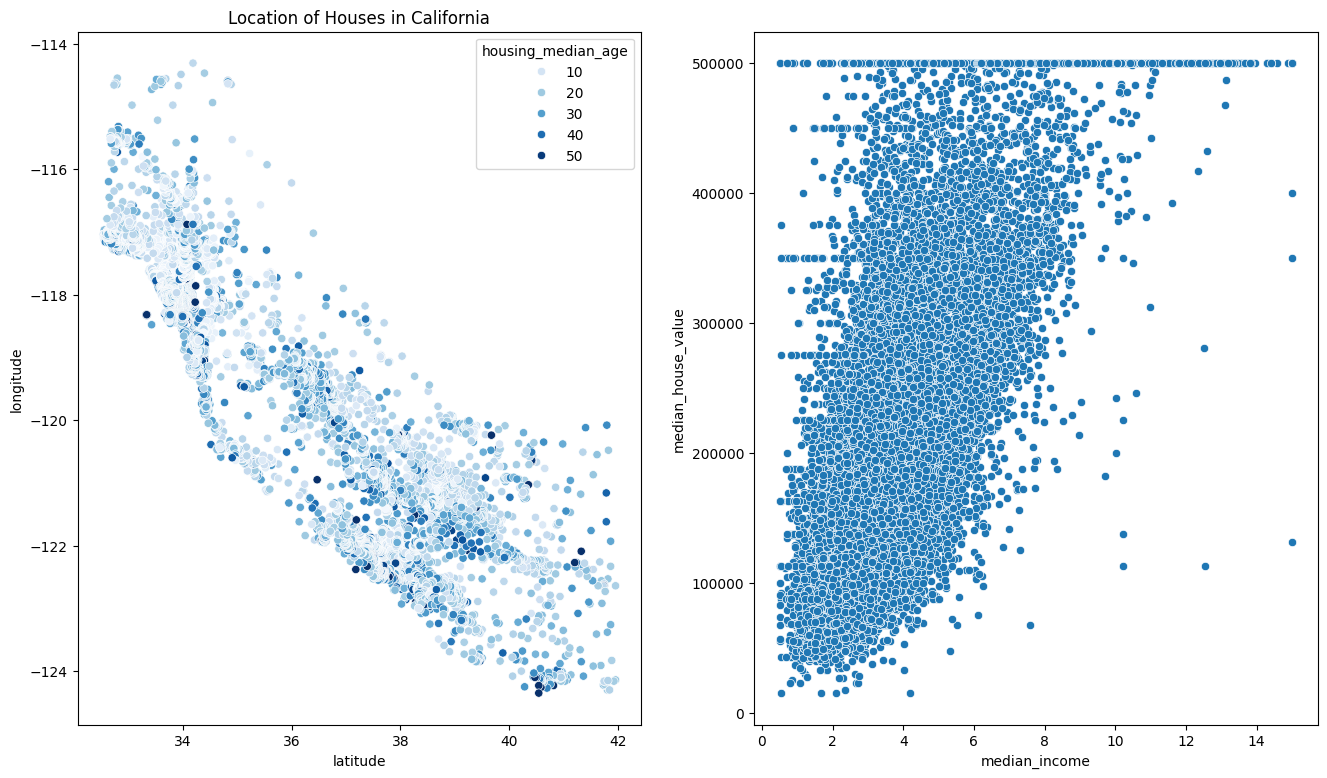

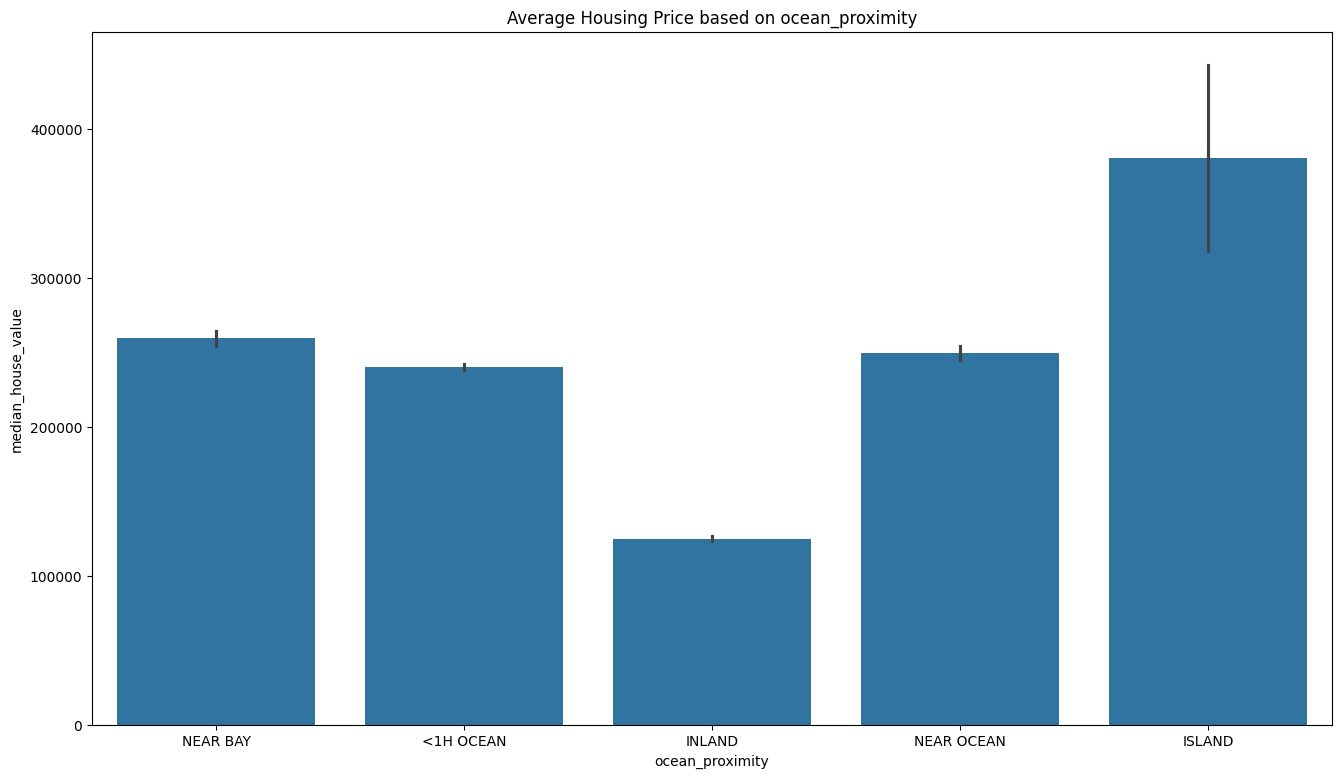

In [3]:
plt.figure(figsize=(16,9))
plt.subplot(1,2,1)
sns.scatterplot(data=df, x='latitude', y='longitude', hue='housing_median_age',palette='Blues')
plt.title("Location of Houses in California")
plt.subplot(1,2,2)
sns.scatterplot(data=df, x='median_income', y='median_house_value')
plt.show()
plt.figure(figsize=(16,9))
sns.barplot(data=df, x='ocean_proximity', y='median_house_value')
plt.title("Average Housing Price based on ocean_proximity")
plt.show()

Text(0.5, 1.0, 'Correlation Heatmap')

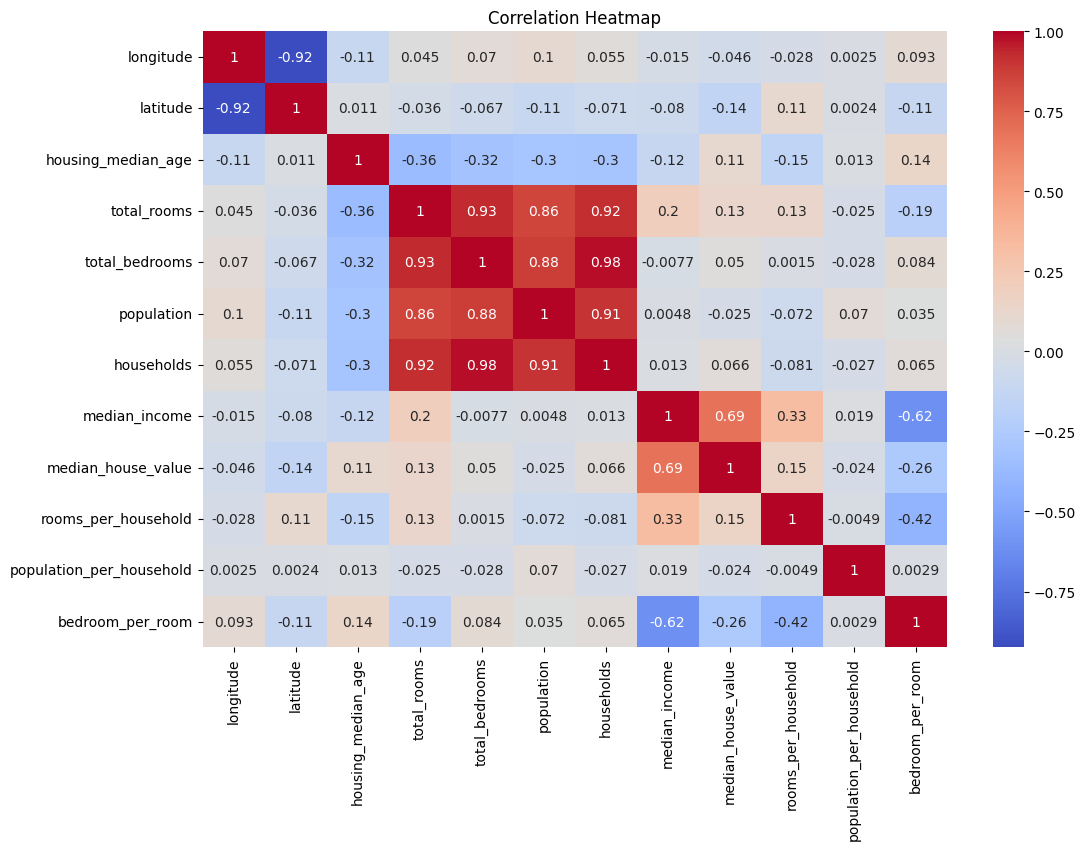

In [4]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")

In [5]:
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,population_per_household,bedroom_per_room
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,2.555556,0.146591
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,2.109842,0.155797
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,2.802260,0.129516
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,2.547945,0.184458
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,2.181467,0.172096
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY,4.761658,2.139896,0.231774
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY,4.931907,2.128405,0.192899
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY,4.797527,1.788253,0.221327
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY,4.294118,2.026891,0.260274
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY,4.970588,2.172269,0.199211


In [6]:
df.drop(['total_rooms', 'total_bedrooms', 'population'], axis=1, inplace=True)

In [7]:
num_col = ['longitude', 'latitude','housing_median_age','households', 'median_income', 'rooms_per_household', 'population_per_household', 'bedroom_per_room']
cat_col = ['ocean_proximity']

X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

num_pipeline = Pipeline(
    steps=[
        ('impute', SimpleImputer(strategy='median')),
        ('scaling', StandardScaler())
    ]
)

cat_pipeline = Pipeline(
    steps=[
        ('cat_impute', SimpleImputer(strategy='most_frequent')),
        ('cat', OneHotEncoder(handle_unknown='ignore',sparse_output=True))
    ]
)

num_process = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_col),
        ('cat', cat_pipeline, cat_col)
    ]
)

lr = LinearRegression()
pipeline = Pipeline(
    steps=[
        ('preprocessing', num_process),
        ('lr', lr)
    ]
)
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [8]:
y_pred1 = pipeline.predict(X_test)

rmse_score1 = root_mean_squared_error(y_test, y_pred1)
print(f"The RMSE score is: {rmse_score1}")

r21 = r2_score(y_test, y_pred1)
print(f"The R2 score is: {r21}")

mse_score = mean_squared_error(y_test, y_pred1)
print(f"The MSE score is: {mse_score}")


The RMSE score is: 71589.22840118984
The R2 score is: 0.6088993811720078
The MSE score is: 5125017623.077727


In [9]:
rf = RandomForestRegressor(n_estimators=50,random_state=42)
pipeline2 = Pipeline(
    steps=[
        ('preprocessing', num_process),
        ('rf', rf)
    ]
)
pipeline2.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [10]:
y_pred = pipeline2.predict(X_test)

rmse_score = root_mean_squared_error(y_test, y_pred)
print(f"The RMSE score is: {rmse_score}")

r2 = r2_score(y_test, y_pred)
print(f"The R2 score is: {r2}")

mse_score = mean_squared_error(y_test, y_pred)
print(f"The MSE score is: {mse_score}")

The RMSE score is: 49871.39718769153
The R2 score is: 0.810199998721677
The MSE score is: 2487156257.452487


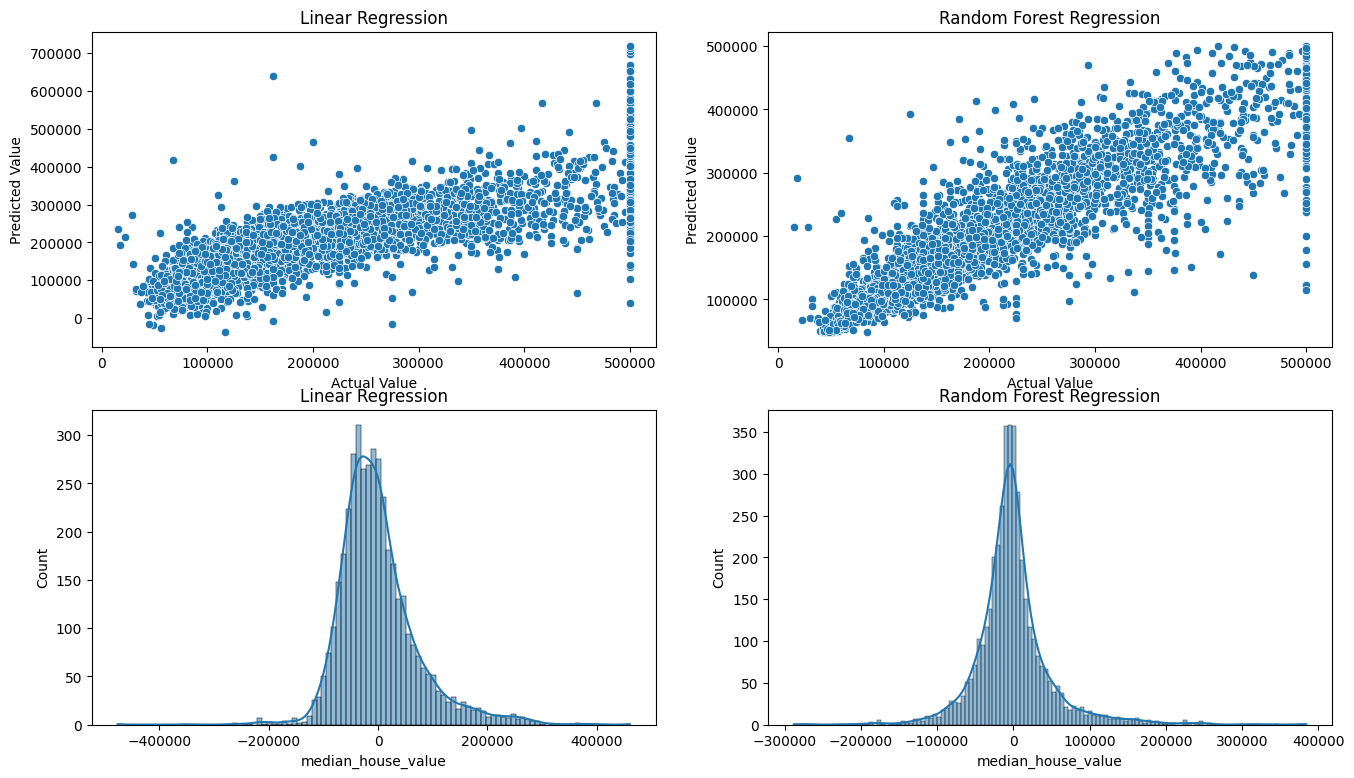

In [11]:
plt.figure(figsize=(16,9))
plt.subplot(2,2,1)
plt.title("Linear Regression")
sns.scatterplot(x=y_test,y=y_pred1)
plt.ylabel("Predicted Value")
plt.xlabel("Actual Value")

plt.subplot(2,2,2)
sns.scatterplot(x=y_test,y=y_pred)
plt.title("Random Forest Regression")
plt.ylabel("Predicted Value")
plt.xlabel("Actual Value")

plt.subplot(2,2,3)
residuals1 = y_test - y_pred1
sns.histplot(residuals1, kde=True)
plt.title("Linear Regression")

plt.subplot(2,2,4)
residuals = y_test - y_pred
sns.histplot(residuals, kde=True)
plt.title("Random Forest Regression")
plt.show()

In [12]:
df.head(10)

,longitude,latitude,housing_median_age,households,median_income,median_house_value,ocean_proximity,rooms_per_household,population_per_household,bedroom_per_room
0,-122.23,37.88,41.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,2.555556,0.146591
1,-122.22,37.86,21.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,2.109842,0.155797
2,-122.24,37.85,52.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,2.802260,0.129516
3,-122.25,37.85,52.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,2.547945,0.184458
4,-122.25,37.85,52.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,2.181467,0.172096
5,-122.25,37.85,52.0,193.0,4.0368,269700.0,NEAR BAY,4.761658,2.139896,0.231774
6,-122.25,37.84,52.0,514.0,3.6591,299200.0,NEAR BAY,4.931907,2.128405,0.192899
7,-122.25,37.84,52.0,647.0,3.1200,241400.0,NEAR BAY,4.797527,1.788253,0.221327
8,-122.26,37.84,42.0,595.0,2.0804,226700.0,NEAR BAY,4.294118,2.026891,0.260274
9,-122.25,37.84,52.0,714.0,3.6912,261100.0,NEAR BAY,4.970588,2.172269,0.199211


In [13]:
ns = pd.DataFrame({
    'longitude': [-120],
    'latitude': [34],
    'housing_median_age': [45],
    'households': [231],
    'median_income': [8.9],
    'ocean_proximity': ['NEAR BAY'],
    'rooms_per_household': [7.342],
    'population_per_household': [5.321],
    'bedroom_per_room': [0.3421]
})
output = pipeline2.predict(ns)
print(output)

[466420.66]


In [16]:
joblib.dump(pipeline2, "pipeline.pkl", compress = 3)
joblib.dump(list(X.columns), "col_names.pkl")

['col_names.pkl']

In [15]:
df['ocean_proximity'].nunique()

5